# 01 - Data Acquisition & EDA
**Assignment:** MLOps AIMLCZG523 - Assignment 1 | **Author:** Pranay Jain

Dataset: UCI Heart Disease (Cleveland subset, 303 patients, 13 features + target).
Steps: load -> profile -> clean -> visualise. Figures are saved to `reports/figures/`.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from heart import config
from heart.data import load_raw, clean, missing_report

sns.set_theme(style="whitegrid", palette="deep")
config.FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(config.FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

raw = load_raw()
print(raw.shape)
raw.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [2]:
raw.info()
raw.describe().T.round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


In [3]:
print("Missing values ('?' in raw file):")
print(missing_report(raw))
print("\nOriginal target `num` (0 = no disease, 1-4 = severity):")
print(raw["num"].value_counts().sort_index())

Missing values ('?' in raw file):
ca      4
thal    2
dtype: int64

Original target `num` (0 = no disease, 1-4 = severity):
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [4]:
df = clean(raw)
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


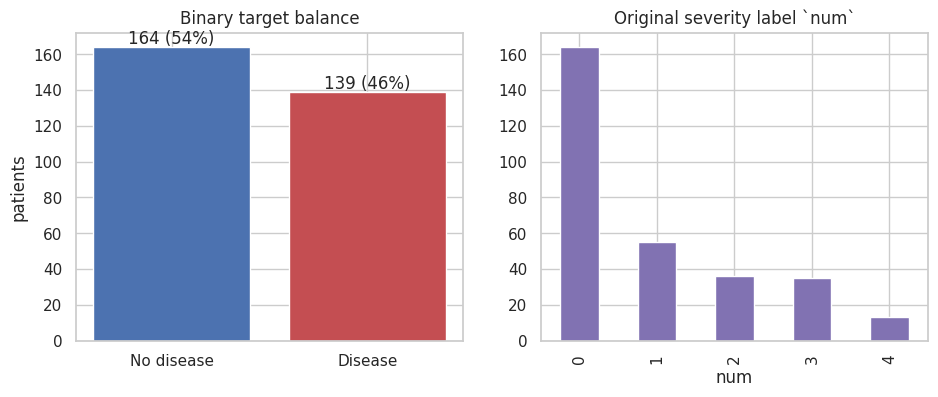

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = df[config.TARGET].map({0: "No disease", 1: "Disease"}).value_counts()
ax[0].bar(counts.index, counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 2, f"{v} ({v/len(df):.0%})", ha="center")
ax[0].set_title("Binary target balance"); ax[0].set_ylabel("patients")
raw["num"].value_counts().sort_index().plot.bar(ax=ax[1], color="#8172B2")
ax[1].set_title("Original severity label `num`"); ax[1].set_xlabel("num")
save(fig, "01_class_balance"); plt.show()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


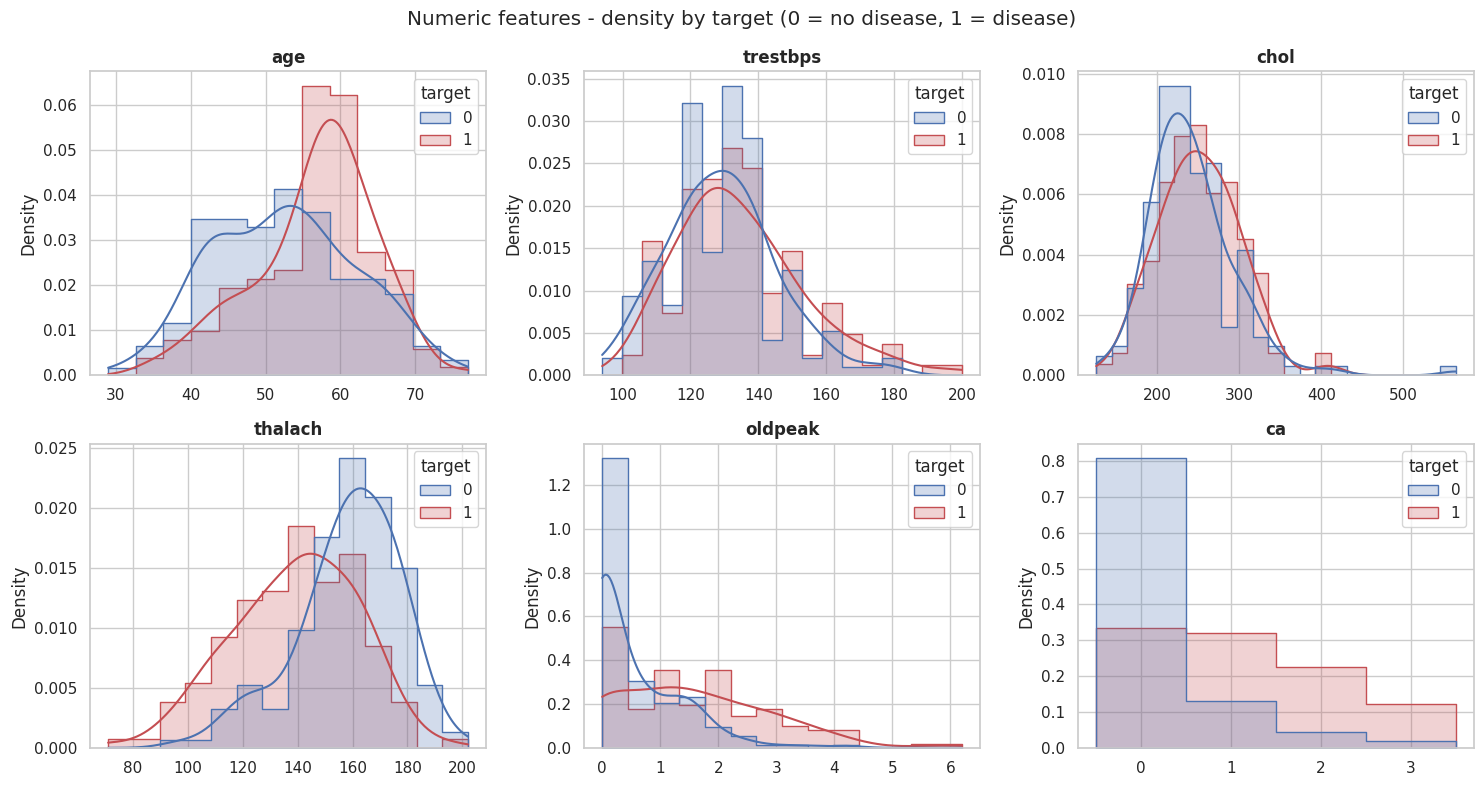

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, config.NUMERIC):
    sns.histplot(data=df, x=col, hue=config.TARGET, kde=(col != "ca"), ax=ax,
                 palette={0: "#4C72B0", 1: "#C44E52"}, element="step",
                 stat="density", common_norm=False, discrete=(col == "ca"))
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
fig.suptitle("Numeric features - density by target (0 = no disease, 1 = disease)")
fig.tight_layout()
save(fig, "02_numeric_histograms"); plt.show()

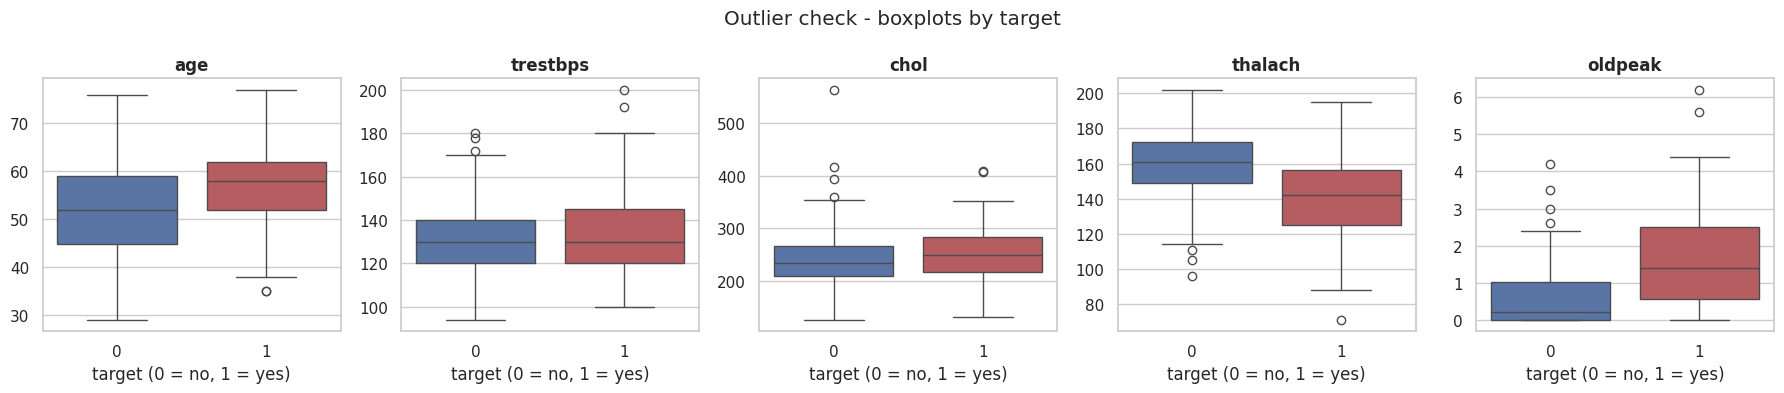

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, ["age", "trestbps", "chol", "thalach", "oldpeak"]):
    sns.boxplot(data=df, x=config.TARGET, y=col, ax=ax, hue=config.TARGET,
                palette={0: "#4C72B0", 1: "#C44E52"}, legend=False)
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("")
    ax.set_xlabel("target (0 = no, 1 = yes)")
fig.suptitle("Outlier check - boxplots by target")
fig.tight_layout()
save(fig, "03_boxplots"); plt.show()

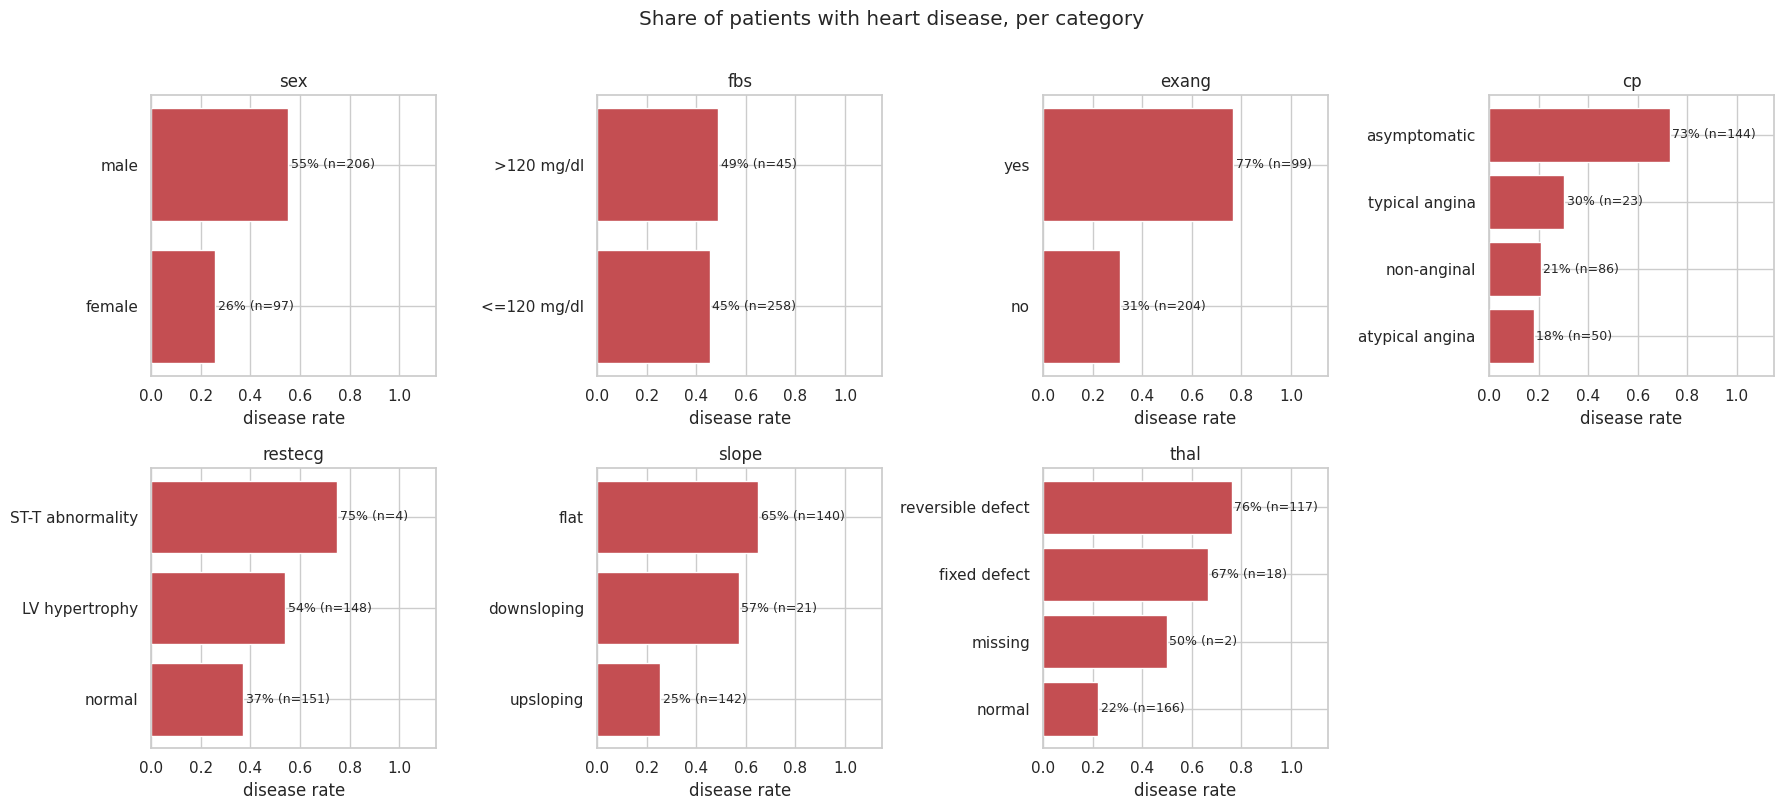

In [8]:
cat_cols = config.BINARY + config.CATEGORICAL
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, cat_cols):
    labels = df[col].map(config.CODE_LABELS.get(col, {})).fillna("missing")
    rate = df.groupby(labels)[config.TARGET].agg(["mean", "size"]).sort_values("mean")
    ax.barh(rate.index.astype(str), rate["mean"], color="#C44E52")
    for i, (m, n) in enumerate(rate.values):
        ax.text(m + 0.01, i, f"{m:.0%} (n={int(n)})", va="center", fontsize=9)
    ax.set_xlim(0, 1.15); ax.set_title(col); ax.set_xlabel("disease rate")
axes.flat[-1].set_visible(False)
fig.suptitle("Share of patients with heart disease, per category", y=1.01)
fig.tight_layout(); save(fig, "04_categorical_rates"); plt.show()

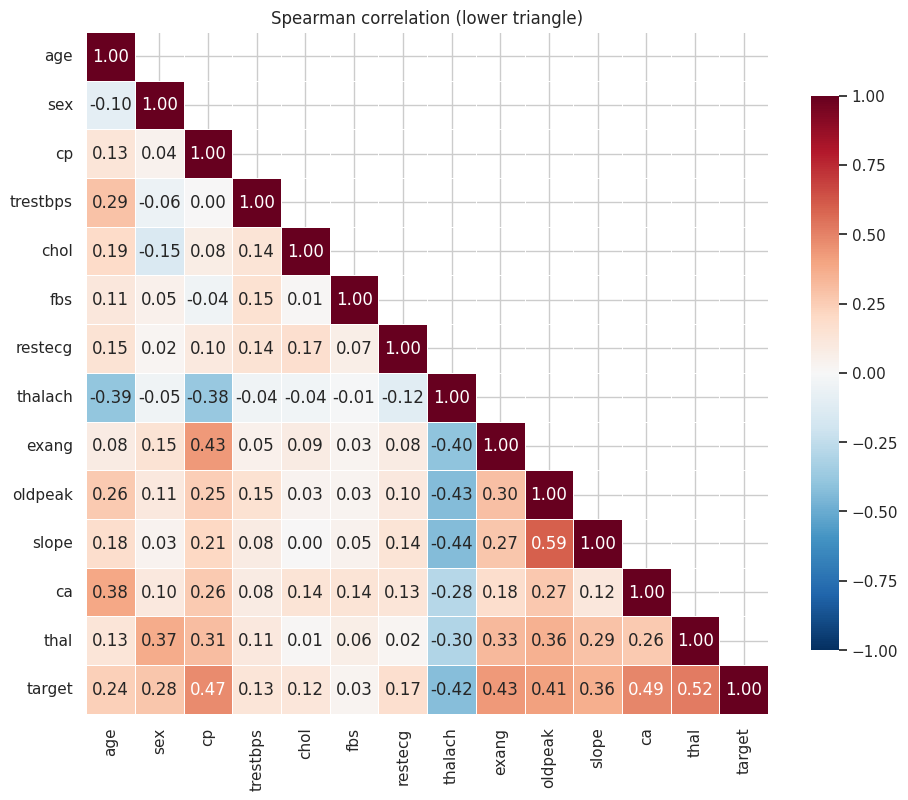

In [9]:
corr = df.astype(float).corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Spearman correlation (lower triangle)")
save(fig, "05_correlation_heatmap"); plt.show()

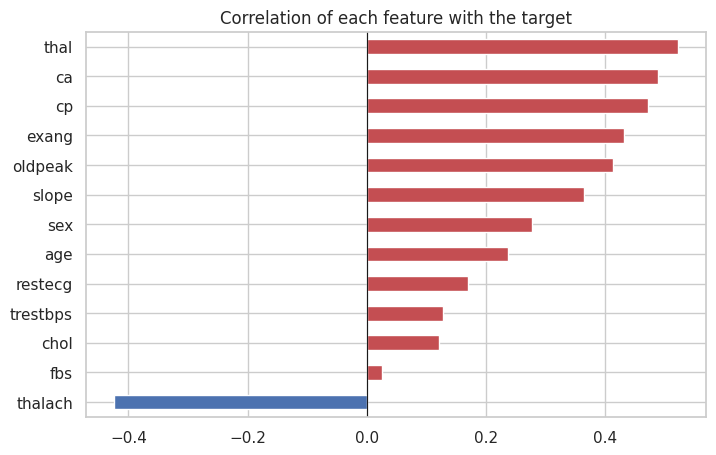

thalach    -0.423
fbs         0.025
chol        0.121
trestbps    0.128
restecg     0.169
age         0.237
sex         0.277
slope       0.364
oldpeak     0.413
exang       0.432
cp          0.472
ca          0.489
thal        0.522
Name: target, dtype: float64

In [10]:
target_corr = corr[config.TARGET].drop(config.TARGET).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
target_corr.plot.barh(ax=ax, color=np.where(target_corr > 0, "#C44E52", "#4C72B0"))
ax.set_title("Correlation of each feature with the target"); ax.axvline(0, color="k", lw=.8)
save(fig, "06_target_correlation"); plt.show()
target_corr.round(3)

## Key observations

1. **Class balance:** 164 patients without disease (54%) vs 139 with disease (46%).
   The classes are roughly balanced, so no resampling (SMOTE etc.) is needed and
   accuracy is meaningful. Still, in a medical setting a missed disease case is worse
   than a false alarm, so I will track **recall** and **ROC-AUC** as the main
   metrics alongside accuracy. Stratified splits keep the 54/46 ratio in every fold.

2. **Strongest features:** 'thal' (reversible defect -> 76% disease vs 22% for normal),
   'ca' (number of vessels), 'cp' (asymptomatic chest pain -> 73% disease, surprisingly
   higher than typical angina), 'exang' (exercise-induced angina -> 77% vs 31%) and
   'oldpeak' (ST depression). 'thalach' (max heart rate) is the strongest *negative*
   signal - patients with disease reach a lower peak heart rate.
   Weakest: 'fbs' (49% vs 45%), 'chol' and 'trestbps' (|corr| ~ 0.12).

3. **Outliers:** a few high values in 'chol' (one > 500 mg/dl), 'trestbps' (~200) and
   'oldpeak' (> 6). They are physiologically possible, all fall inside the valid
   ranges I set in 'config.VALID_RANGES', so I kept them. Tree models (RF, XGBoost)
   are robust to outliers, and scaling limits their effect on Logistic Regression.

4. **Missing values & handling:** only 6 values are missing - 'ca' (4) and 'thal' (2),
   coded as '?' in the raw file. I did **not** drop rows (only 303 samples) and did
   not fill them during cleaning. Instead they are imputed inside the sklearn pipeline
   (median for numeric, most-frequent for categorical), fitted on training folds only,
   which avoids data leakage and lets the deployed API handle a missing field the same way.

5. **Correlated feature pairs:** 'oldpeak' and 'slope' (0.6), 'thalach' with 'age',
   'slope' and 'exang' (-0.4). No pair is above 0.7, so multicollinearity is not a
   serious problem; L2 regularisation in Logistic Regression handles the moderate
   correlations. Note: 'cp', 'thal', 'restecg' are nominal categories, so correlation on
   their numeric codes is only indicative - they will be one-hot encoded for modelling.
   Small groups ('restecg' ST-T abnormality n=4, 'thal' missing n=2) should not be
   over-interpreted.